# Microstructure Features

**Chapter 8: Feature Engineering**
**Section Reference**: 8.2 - Price-Derived Features (Microstructure)
**Docker image**: `ml4t`

## Purpose

Microstructure features capture market dynamics invisible in daily OHLCV data.
They proxy for **liquidity**, **information flow**, and **execution quality**.

## Learning Objectives

1. Compute trade-based liquidity features (Kyle λ, Amihud, Roll spread)
2. Understand order flow imbalance and its predictive content
3. Distinguish between **flow features** and **state features** (critical!)
4. Know which features are alpha vs feasibility/cost inputs

## Feature Categories

| Category | Features | Data Required |
|----------|----------|---------------|
| **Liquidity** | Kyle λ, Amihud, Roll | OHLCV bars |
| **Order Flow** | OFI, trade intensity | Trade data |
| **Book State** | Spread, depth | LOB snapshots |

## Data Policy

Uses **real NASDAQ ITCH data**. The notebook raises a clear error when ITCH
is missing rather than substituting a synthetic toy panel.

In [1]:
"""Microstructure Features: trade-based liquidity and order flow features from tick data."""

from __future__ import annotations

from datetime import time

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.reproducibility import set_global_seeds
from utils.style import (  # importing utils.style sets the ml4t Plotly template as default
    COLORS,
    show_plotly_with_alt,
)

In [2]:
SEED = 42

In [3]:
set_global_seeds(SEED)

## Data Loading with Availability Check

Microstructure analysis requires high-frequency data. The loader raises
a clear error if ITCH is missing, with no silent fallback to synthetic data.

The loader fails loudly when ITCH is missing rather than silently substituting a
synthetic toy panel, so a green run of this notebook means it read real trade data.

In [4]:
from data import load_nasdaq_itch

sample = load_nasdaq_itch(message_types=["P"], symbols=["AAPL"])
if len(sample) < 100:
    raise RuntimeError(
        f"Expected NASDAQ ITCH trade data with >=100 rows for AAPL; got {len(sample)}. "
        "Ensure ML4T_DATA_PATH is set and the ITCH dataset is downloaded."
    )
print(f"ITCH data available: {len(sample):,} trade messages loaded")

ITCH data available: 15,114 trade messages loaded


In [5]:
trades = load_nasdaq_itch(message_types=["P"], symbols=["AAPL", "MSFT", "TSLA"])

# Convert price from 10,000ths to dollars
trades = trades.with_columns((pl.col("price") / 10000.0).alias("price"))

# Filter to regular trading hours
trades = trades.filter(
    (pl.col("timestamp").dt.time() >= time(9, 30)) & (pl.col("timestamp").dt.time() < time(16, 0))
).sort(["stock", "timestamp"])

print(f"Loaded {len(trades):,} trades across {trades['stock'].n_unique()} stocks")
_days = trades["timestamp"].dt.date().n_unique()
print(
    f"spanning {_days} trading day(s): {trades['timestamp'].min()} to {trades['timestamp'].max()}"
)

Loaded 88,572 trades across 3 stocks
spanning 1 trading day(s): 2020-01-30 09:30:00.002266 to 2020-01-30 15:59:59.999044


Read the span printed above before reading any number in this notebook. The ITCH
fixture is a single session, so every statistic below is computed on one day of one
venue's trades. That is enough to show how each feature is built and what it responds
to, and it is not enough to establish anything about how these features behave in
general. Where a number would ordinarily invite a conclusion, the text says what the
sample can and cannot support.

## Aggregate to Bars

Trade-based features work on aggregated bars (not tick-by-tick).
Common intervals: 1m, 5m, 15m for intraday; daily for cross-sectional.

In [6]:
from ml4t.engineer.features.microstructure import effective_tick_rule


def aggregate_to_bars(
    trades: pl.DataFrame,
    interval: str = "5m",
    stock_col: str = "stock",
    price_col: str = "price",
    volume_col: str = "shares",
) -> pl.DataFrame:
    """Aggregate trades to OHLCV bars with a trade-level buy/sell volume split.

    Order flow imbalance is a *flow* feature: it must be built from the sign of
    individual trades and then aggregated. We classify every trade with the tick
    rule (buyer- vs seller-initiated) BEFORE aggregating, so each bar carries a
    genuine ``buy_volume``/``sell_volume`` split. Classifying the bar *close*
    instead would only recover the sign of the bar's own return, collapsing OFI
    to +/-1 rather than measuring imbalance.
    """
    classified = trades.sort([stock_col, "timestamp"]).with_columns(
        effective_tick_rule(price_col).over(stock_col).alias("trade_sign")
    )
    bars = (
        classified.group_by_dynamic("timestamp", every=interval, group_by=stock_col)
        .agg(
            [
                pl.col(price_col).first().alias("open"),
                pl.col(price_col).max().alias("high"),
                pl.col(price_col).min().alias("low"),
                pl.col(price_col).last().alias("close"),
                pl.col(volume_col).sum().alias("volume"),
                pl.len().alias("trade_count"),
                pl.col(volume_col).filter(pl.col("trade_sign") > 0).sum().alias("buy_volume"),
                pl.col(volume_col).filter(pl.col("trade_sign") < 0).sum().alias("sell_volume"),
            ]
        )
        .sort([stock_col, "timestamp"])
    )

    # Add returns, dollar volume, and the genuine per-bar OFI. Cast the summed
    # share volumes to a signed dtype before subtracting: ``shares`` is unsigned
    # (UInt32), so buy - sell would silently underflow on net-selling bars.
    return bars.with_columns(
        [
            (pl.col("close") / pl.col("close").shift(1).over(stock_col) - 1).alias("returns"),
            (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
            pl.when((pl.col("buy_volume") + pl.col("sell_volume")) > 0)
            .then(
                (pl.col("buy_volume").cast(pl.Int64) - pl.col("sell_volume").cast(pl.Int64))
                / (pl.col("buy_volume") + pl.col("sell_volume"))
            )
            .otherwise(0.0)
            .alias("ofi"),
        ]
    )


# Create 5-minute bars
bars = aggregate_to_bars(trades, interval="5m")
print(f"Aggregated to {len(bars):,} bars")
print(f"Columns: {bars.columns}")

# Focus on one stock for visualization
FOCUS_STOCK = "AAPL"
focus_bars = bars.filter(pl.col("stock") == FOCUS_STOCK).drop_nulls(["returns"])
print(f"\n{FOCUS_STOCK}: {len(focus_bars):,} bars")

Aggregated to 234 bars
Columns: ['stock', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'buy_volume', 'sell_volume', 'returns', 'dollar_volume', 'ofi']

AAPL: 77 bars


## Trade-Based Liquidity Features

These features require only OHLCV bars (widely available).
They proxy for market liquidity and trading costs.

| Feature | What the library computes here | Interpretation |
|---------|-------------------------------|----------------|
| Kyle λ | mean of \|r\| / (V / V̄), over the window | Return per unit of *relative* volume |
| Amihud | mean of \|r\| / DollarVol × 10⁶, over the window | Return per *million* dollars traded |
| Roll Spread | 2√(-Cov(ΔP_t, ΔP_{t-1})) | Implied bid-ask spread |

The Kyle row is the one to read carefully. `kyle_lambda` takes a `method` argument that
defaults to `"ratio"`, and `method="regression"` raises `NotImplementedError` in the
installed version, so what this notebook computes is the ratio approximation above and
not the regression slope of Kyle (1985). Both are called Kyle lambda. Only one of them
is a covariance, and it is not the one running here.

In [7]:
from ml4t.engineer.features.microstructure import (
    amihud_illiquidity,
    kyle_lambda,
    roll_spread_estimator,
    trade_intensity,
)

# Compute the trade-based liquidity features. ``ofi`` already lives on the bars
# (built from the trade-level buy/sell split in aggregate_to_bars), so it is not
# recomputed here.
PERIOD = 20

features_df = focus_bars.with_columns(
    [
        # Liquidity measures
        kyle_lambda("returns", "volume", period=PERIOD).alias("kyle_lambda"),
        amihud_illiquidity("returns", "volume", "close", period=PERIOD).alias("amihud"),
        roll_spread_estimator("close", period=PERIOD).alias("roll_spread"),
        trade_intensity("volume", period=PERIOD).alias("trade_intensity"),
    ]
)

features_df = features_df.drop_nulls(["kyle_lambda", "amihud"])

print("Trade-based features computed:")
features_df.select(["timestamp", "close", "kyle_lambda", "amihud", "roll_spread", "ofi"]).tail(10)

Trade-based features computed:


timestamp,close,kyle_lambda,amihud,roll_spread,ofi
datetime[ns],f64,f64,f64,f64,f64
2020-01-30 15:10:00,321.08,0.001004,0.000565,0.316581,-0.082348
2020-01-30 15:15:00,321.71,0.001066,0.000565,0.235676,0.421245
2020-01-30 15:20:00,322.23,0.001143,0.000586,0.064782,0.447878
2020-01-30 15:25:00,321.77,0.001174,0.000557,0.207022,-0.131579
2020-01-30 15:30:00,322.05,0.001106,0.000494,0.214769,0.068913
2020-01-30 15:35:00,322.355,0.00113,0.000487,0.197683,0.054177
2020-01-30 15:40:00,322.72,0.001154,0.000492,0.174818,0.023755
2020-01-30 15:45:00,323.085,0.001169,0.000484,0.156797,0.162584
2020-01-30 15:50:00,323.38,0.001077,0.000409,0.222852,0.046178


**Interpretation**: both measures are an absolute return divided by a volume, averaged
over the window, so neither carries a direction and the difference between them is
entirely in the denominator. Kyle's ratio divides by volume *relative to its own rolling
mean*; Amihud divides by dollar volume in dollars. Naming both "illiquidity" invites the
assumption that they agree, and the correlation printed under the next figure says how
far that holds on this session.

### Kyle Lambda (Price Impact)

High Kyle λ means prices move a lot per unit of volume: the market is **illiquid**
and trades have high impact.

Kyle (1985) defines λ as the slope of returns on signed order flow, which is a
regression coefficient:

$$r_t = \lambda \, S_t + \varepsilon_t$$

The installed `ml4t-engineer` does not fit that regression. Its default `method="ratio"`
averages a per-bar ratio over the window instead, with volume normalized by its own
rolling mean:

$$\lambda_{\text{ratio}} = \text{mean}_{t}\!\left(\frac{|r_t|}{V_t / \bar{V}_t}\right)$$

Read the second formula when reading the figure below, because the second formula is
what produced it. The two agree on the direction of "less liquid" and they are not the
same statistic: the ratio uses the absolute return and so has no sign, while the
regression slope does.

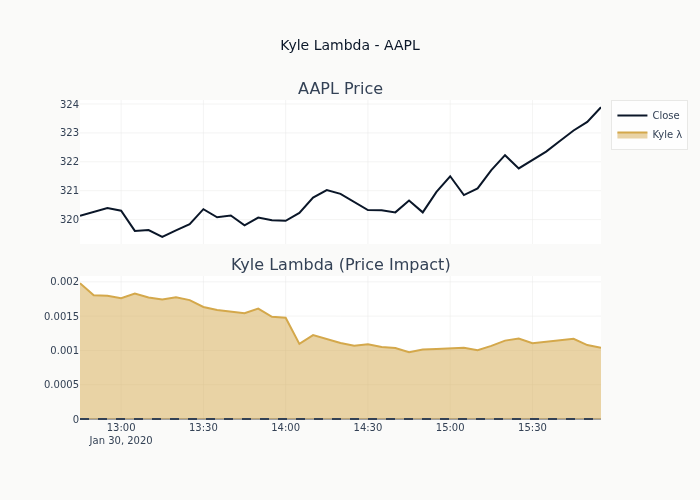

In [8]:
# Visualize Kyle Lambda
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[f"{FOCUS_STOCK} Price", "Kyle Lambda (Price Impact)"],
    vertical_spacing=0.1,
)

# The fixture holds one session, so this takes every bar there is rather than a tail.
n = min(len(features_df), 200)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["close"].to_list()[-n:],
        name="Close",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["kyle_lambda"].to_list()[-n:],
        name="Kyle λ",
        fill="tozeroy",
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

fig.update_layout(height=500, title=f"Kyle Lambda - {FOCUS_STOCK}")
show_plotly_with_alt(
    fig,
    (
        "Two stacked panels sharing a time axis across the afternoon of a single trading "
        "session in January 2020. The top panel plots the AAPL close, which drifts "
        "sideways and slightly lower through the early afternoon, then climbs steadily "
        "into the final hour to finish at the high of the window. The bottom panel fills "
        "Kyle lambda, the price impact per unit of volume, in amber above a dashed zero "
        "line. It begins at its highest value on the left and declines through the "
        "session, with a distinct step down shortly after two o'clock, after which it "
        "holds a lower and flatter level to the close."
    ),
)

### Amihud Illiquidity

Amihud ratio measures absolute return per dollar traded. Higher = more illiquid.

$$\text{Amihud} = \frac{1}{N} \sum_t \frac{|r_t|}{\text{DollarVolume}_t}$$

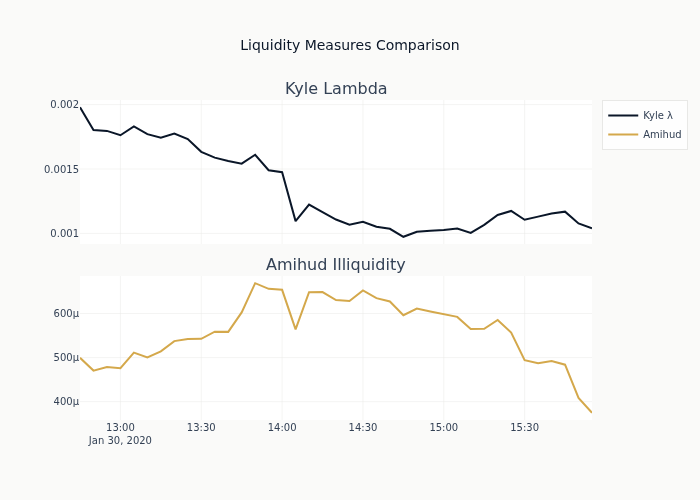

Kyle lambda vs Amihud, over 39 bars of one session:
  Pearson  -0.260
  Spearman -0.348


In [9]:
# Amihud vs Kyle comparison
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Kyle Lambda", "Amihud Illiquidity"],
    vertical_spacing=0.1,
)

fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["kyle_lambda"].to_list()[-n:],
        name="Kyle λ",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["amihud"].to_list()[-n:],
        name="Amihud",
    ),
    row=2,
    col=1,
)

fig.update_layout(height=500, title="Liquidity Measures Comparison")
show_plotly_with_alt(
    fig,
    (
        "Two stacked panels sharing a time axis across the afternoon of a single trading "
        "session in January 2020, each on its own vertical scale because the two measures "
        "are in different units. The top panel plots Kyle lambda in dark blue, declining "
        "from its highest value on the left through a step down shortly after two "
        "o'clock to a lower, flatter level for the rest of the window. The bottom panel "
        "plots Amihud illiquidity in amber, which runs the other way over the same hours: "
        "it rises from the left to a broad peak in the middle of the window, then falls "
        "through the last hour to finish at its lowest point."
    ),
)


# Both, and named: pl.corr is Pearson by default, which measures level co-movement,
# while the question "do the two measures agree on which bars are illiquid" is a ranking
# question and wants Spearman.
def fmt(value: float | None, spec: str = "+.3f", absent: str = "undefined") -> str:
    """Format a statistic that a short sample can leave undefined.

    polars returns a null, not an error, when a correlation or a median has nothing to
    work with: a constant column, fewer than two non-null rows, an empty frame. Those
    arrive here as None and `format` raises TypeError on them, which stops the notebook
    on a smaller slice of data while working on a larger one.
    """
    return absent if value is None else format(value, spec)


corr_pearson = features_df.select(pl.corr("kyle_lambda", "amihud")).item()
corr_spearman = features_df.select(pl.corr("kyle_lambda", "amihud", method="spearman")).item()
print(f"Kyle lambda vs Amihud, over {len(features_df)} bars of one session:")
print(f"  Pearson  {fmt(corr_pearson)}")
print(f"  Spearman {fmt(corr_spearman)}")

Both correlations are negative on this session, which the figure above shows directly:
Kyle lambda falls through the afternoon while Amihud rises to a midday peak before
dropping away. Two measures that a reader would reasonably expect to agree are moving
against each other, and the sign is the thing to notice rather than the magnitude, which
one session of one name does not pin down.

The denominators differ in one respect that is easy to check: what happens if every
volume is multiplied by a constant, returns and prices left alone. Kyle's ratio divides
volume by its own rolling mean, so the constant cancels. Amihud divides by dollar volume
in dollars, so the constant passes through. The cell below runs that substitution and
prints both ratios to the original.

Read it for what it is. It establishes that the two measures answer differently to the
units volume is quoted in, and it does not by itself explain the negative correlation
above, which arises from returns, prices and volumes all moving together across the
session. The cross-stock section later in this notebook does the decomposition that
explains the disagreement.

In [10]:
# Scale every volume by a constant and recompute. One measure is invariant, one is not.
VOLUME_SCALE = 10

_scaled = features_df.with_columns((pl.col("volume") * VOLUME_SCALE).alias("volume")).with_columns(
    [
        kyle_lambda("returns", "volume", period=PERIOD).alias("kyle_scaled"),
        amihud_illiquidity("returns", "volume", "close", period=PERIOD).alias("amihud_scaled"),
    ]
)
print(f"with every volume multiplied by {VOLUME_SCALE}, the median ratio to the original:")
print(f"  Kyle lambda {fmt((_scaled['kyle_scaled'] / _scaled['kyle_lambda']).median(), '.3f')}")
print(f"  Amihud      {fmt((_scaled['amihud_scaled'] / _scaled['amihud']).median(), '.3f')}")

with every volume multiplied by 10, the median ratio to the original:
  Kyle lambda 1.000
  Amihud      0.100


What the substitution shows: Kyle's ratio is unchanged and Amihud moves by the
reciprocal of the factor. The measures are not on a common footing, and a threshold
tuned on one says nothing about the other.

## Order Flow Imbalance (OFI)

OFI measures the buy-sell imbalance within a bar, proxying for **net order
flow**:

$$\text{OFI} = \frac{V_{buy} - V_{sell}}{V_{buy} + V_{sell}}$$

**Important**: Without exchange-provided buy/sell labels we estimate the side
of each trade with the **tick rule** (Lee-Ready), classifying it buyer- or
seller-initiated from the sign of the price change. That classification has to
happen at the **trade** level, before aggregation, which is why
`aggregate_to_bars` splits `buy_volume`/`sell_volume` there. Applying the tick
rule to a *bar's* single close would collapse OFI to the sign of that bar's
own return (+/-1), a tautology rather than a flow measure. This is the concrete
reason OFI is a **flow** feature that needs trade data, not a bar-OHLCV
feature which is the flow-versus-state distinction this chapter turns on.

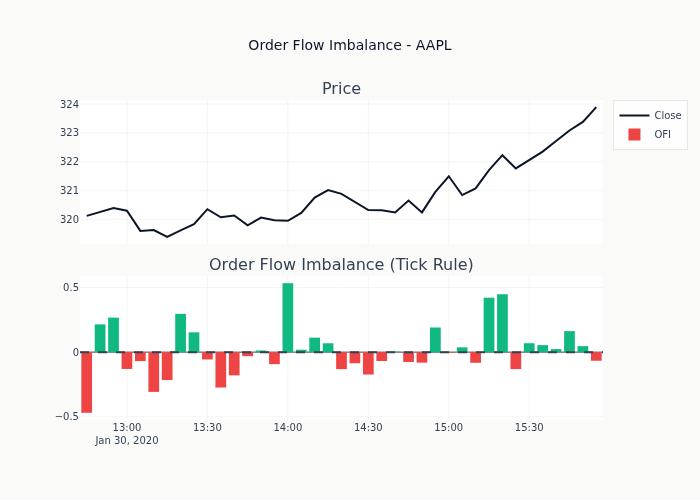

In [11]:
# OFI visualization
ofi_colors = [
    COLORS["positive"] if x > 0 else COLORS["negative"] for x in features_df["ofi"].to_list()[-n:]
]

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price", "Order Flow Imbalance (Tick Rule)"],
    vertical_spacing=0.1,
)

fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["close"].to_list()[-n:],
        name="Close",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["ofi"].to_list()[-n:],
        marker_color=ofi_colors,
        name="OFI",
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

fig.update_layout(height=500, title=f"Order Flow Imbalance - {FOCUS_STOCK}")
show_plotly_with_alt(
    fig,
    (
        "Two stacked panels sharing a time axis across the afternoon of a single trading "
        "session in January 2020. The top panel plots the AAPL close, flat to slightly "
        "lower early and climbing into the final hour. The bottom panel draws order flow "
        "imbalance as one bar per five-minute bar, green above a dashed zero line where "
        "buying dominates and red below it where selling does. The bars change sign "
        "frequently rather than persisting in one direction; the tallest green bar sits "
        "just before two o'clock and the deepest red bar is the first of the window."
    ),
)

## Feature Timing: Alpha vs Feasibility

**Critical distinction**: Some microstructure features are alpha signals;
others are feasibility/cost state variables.

| Feature | Category | Lag Requirement | Use Case |
|---------|----------|-----------------|----------|
| **OFI** | Alpha | Lagged 1+ bar | Predict next-bar returns |
| **Kyle λ** | Feasibility | Contemporaneous OK | Execution cost estimate |
| **Amihud** | Feasibility | Contemporaneous OK | Position sizing |
| **Trade Intensity** | Context | Contemporaneous OK | Regime detection |

### Alpha Features Must Be Lagged

When using OFI or similar flow features as **predictors**, you must lag them
to avoid look-ahead bias:

```python
# WRONG: using contemporaneous OFI to predict same-bar returns
df["signal"] = df["ofi"]  # Look-ahead!

# CORRECT: use lagged OFI
df["signal"] = df["ofi"].shift(1)  # Predicts next bar
```

In [12]:
# Contrast the leaky same-bar reading with the honest predictive one.
alpha_df = features_df.with_columns(
    # Next-bar return as the prediction target
    pl.col("returns").shift(-1).alias("fwd_return"),
)
alpha_df = alpha_df.drop_nulls(["ofi", "returns", "fwd_return"])

# Same-bar OFI vs same-bar return: mechanically strong because a bar with a buy
# imbalance is usually an up bar, so using it as a signal peeks at the outcome.
corr_same = alpha_df.select(pl.corr("ofi", "returns")).item()
# Same OFI against the NEXT bar's return: the honest, tradable predictive content.
corr_pred = alpha_df.select(pl.corr("ofi", "fwd_return")).item()


def pearson_interval(r: float | None, n: int, z_crit: float = 1.96) -> tuple[float, float] | None:
    """A 95% interval for a Pearson correlation, via the Fisher z transform.

    None when the interval is not defined: an undefined correlation, or fewer than four
    observations, where the transform's standard error divides by zero.
    """
    if r is None or n < 4:
        return None
    z, se = np.arctanh(r), 1.0 / np.sqrt(n - 3)
    return float(np.tanh(z - z_crit * se)), float(np.tanh(z + z_crit * se))


_n = len(alpha_df)
print(f"OFI predictive content (n={_n} bars):")
for _label, _r in (
    ("same-bar OFI vs same-bar return", corr_same),
    ("OFI vs next-bar return", corr_pred),
):
    _interval = pearson_interval(_r, _n)
    if _interval is None:
        print(f"  {_label:<34} {fmt(_r, '+.4f')}   interval undefined on {_n} bars")
        continue
    _lo, _hi = _interval
    _verdict = "excludes zero" if _lo * _hi > 0 else "includes zero"
    print(f"  {_label:<34} {_r:+.4f}   95% interval ({_lo:+.3f}, {_hi:+.3f}), {_verdict}")

OFI predictive content (n=38 bars):
  same-bar OFI vs same-bar return    +0.5220   95% interval (+0.243, +0.721), excludes zero
  OFI vs next-bar return             +0.2133   95% interval (-0.114, +0.499), includes zero


**Interpretation**: the same-bar correlation is the larger of the two, and it is the one
that cannot be traded. A bar with a buy imbalance is usually a bar whose price rose, so
the same-bar number is mostly the definition of an up bar read back to you; a strategy
that uses it is assuming it knows the bar's outcome while the bar is still open. The gap
between the two numbers is what look-ahead bias is worth here.

The lagged correlation is the one a strategy could act on, and this sample does not
establish that it is different from zero: its interval spans zero while the same-bar
interval does not. That is the honest reading, and it is not a disappointing one. What
the notebook demonstrates is the construction and the size of the bias, both of which
are visible in a single session. Whether lagged OFI carries tradable content is a
question for many sessions and many names, and the right response to a wide interval is
to widen the sample rather than to quote the point estimate.

## Flow vs State: Critical Distinction

> **WARNING: Flow vs State Confusion**
>
> Many practitioners confuse **flow features** (events over a window) with
> **state features** (snapshot at a point in time).

| Concept | Example | Correct Computation |
|---------|---------|---------------------|
| **Flow** | Trades in last 5 min | Count events in window |
| **State** | Current bid-ask spread | Snapshot of book state |
| **Flow** | Volume imbalance | Sum buy vs sell volume |
| **State** | Book depth at best bid | Current LOB level |

### Order Book Spread: A State Feature

The bid-ask spread is a **state** property: the current top of book.
You cannot compute it from order **flow** (arrivals) because:

1. Cancellations remove orders but aren't in arrival flow
2. Executions remove orders from the book
3. The book has memory; flow only captures additions

**Correct approach**: Reconstruct the full LOB state (see Chapter 3).

In [13]:
# Demonstration: Flow-based "spread" is NOT the real spread
print("For LOB state reconstruction, see Chapter 3 notebooks.")
print("This notebook focuses on trade-based features (flow only).")

For LOB state reconstruction, see Chapter 3 notebooks.
This notebook focuses on trade-based features (flow only).


## Composite Liquidity Score

Combining multiple liquidity metrics into a single score via z-score
normalization then summation.

### Scope: descriptive composite construction, not a prediction signal

The z-scores below use **full-sample** mean and standard deviation across the
entire history of each metric. The resulting composite is an *ex-post*
characterization of how the three illiquidity measures combine on this sample, which is
what the dashboard below needs. It is **not** a lookahead-safe feature: each z-score
divides by a mean and variance taken over the whole history, future bars included, so
`illiquidity_score` carries information from after the bar it is attached to. Feed it to
a regression and the fit is scored partly on knowledge the model would not have had.

The lookahead-safe construction (expanding-window percentiles / rolling
z-scores) is demonstrated in
[`06_robustness_sensitivity.py`](06_robustness_sensitivity.ipynb), which
uses expanding-window quantiles to threshold a state variable without
leaking future values, and again in the per-case-study feature pipelines
under `case_studies/*/data/features/` where production features are
constructed inside walk-forward folds.

In [14]:
# Z-score normalize each feature (full-sample for illustration)
liquidity_features = ["kyle_lambda", "amihud", "roll_spread"]

for feat in liquidity_features:
    mean_val = features_df[feat].mean()
    std_val = features_df[feat].std()
    if std_val is None or std_val == 0:
        std_val = 1.0
    features_df = features_df.with_columns(
        ((pl.col(feat) - mean_val) / std_val).alias(f"{feat}_z")
    )  # Full-sample z-score; use rolling in production

# Composite illiquidity score
features_df = features_df.with_columns(
    (pl.col("kyle_lambda_z") + pl.col("amihud_z") + pl.col("roll_spread_z")).alias(
        "illiquidity_score"
    )
)

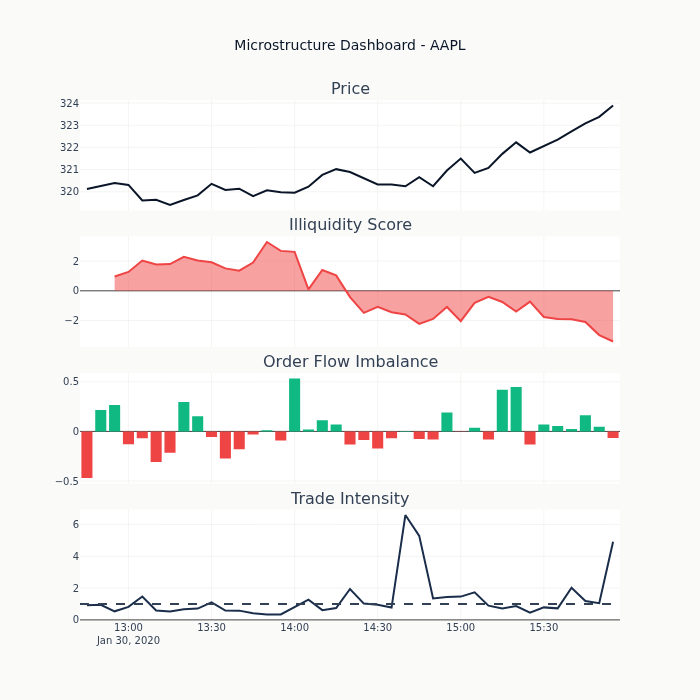

In [15]:
# Dashboard visualization
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price", "Illiquidity Score", "Order Flow Imbalance", "Trade Intensity"],
    vertical_spacing=0.05,
)

fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["close"].to_list()[-n:],
        name="Price",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["illiquidity_score"].to_list()[-n:],
        name="Illiquidity",
        fill="tozeroy",
        line=dict(color=COLORS["negative"]),
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["ofi"].to_list()[-n:],
        marker_color=ofi_colors,
        name="OFI",
    ),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["trade_intensity"].to_list()[-n:],
        name="Intensity",
        line=dict(color=COLORS["slate"]),
    ),
    row=4,
    col=1,
)
fig.add_hline(y=1.0, line_dash="dash", line_color=COLORS["neutral"], row=4, col=1)

fig.update_layout(height=700, title=f"Microstructure Dashboard - {FOCUS_STOCK}", showlegend=False)
show_plotly_with_alt(
    fig,
    (
        "Four stacked panels sharing a time axis across the afternoon of a single trading "
        "session in January 2020. The first plots the AAPL close, flat to slightly lower "
        "early and climbing into the final hour. The second fills the composite "
        "illiquidity score in red around a zero line: positive through the first part of "
        "the window with a peak near its middle, crossing below zero shortly before half "
        "past two, then drifting down to its most negative value at the close. The third "
        "repeats the order flow imbalance bars, green where buying dominates and red "
        "where selling does. The fourth plots trade intensity against a dashed reference "
        "line at one, close to that line for most of the window apart from a tall spike "
        "in the middle of the afternoon and a rise at the very end."
    ),
)

## Cross-Stock Comparison

Microstructure features help identify which stocks are more liquid
and thus have lower trading costs.

The summary below carries the two estimators and the quantities they are built from, so
the orderings can be traced rather than asserted. The last column is Amihud's own per-bar
ratio, formed bar by bar and then summarised: a median of ratios, not a ratio of medians.
The distinction matters because a ratio of medians discards the pairing between each
return and the dollar volume that accompanied it, and can order the names differently.

In [16]:
# Compute features for all stocks
all_features = bars.with_columns(
    [
        kyle_lambda("returns", "volume", period=PERIOD).alias("kyle_lambda"),
        amihud_illiquidity("returns", "volume", "close", period=PERIOD).alias("amihud"),
    ]
).drop_nulls(["kyle_lambda", "amihud"])

# Summary by stock
summary = (
    all_features.group_by("stock")
    .agg(
        [
            pl.col("kyle_lambda").median().alias("kyle_median"),
            pl.col("amihud").median().alias("amihud_median"),
            # The quantities the estimators are built from (see the note below the cell).
            pl.col("returns").abs().median().alias("abs_return_median"),
            (pl.col("close") * pl.col("volume")).median().alias("dollar_volume_median"),
            (pl.col("returns").abs() / (pl.col("close") * pl.col("volume")) * 1e6)
            .median()
            .alias("return_per_mm"),
            pl.len().alias("n_bars"),
        ]
    )
    .sort("kyle_median")
)

print("Liquidity Summary by Stock:")
print(summary)

print()
print("orderings, smallest value first:")
for _col, _label in (
    ("kyle_median", "Kyle lambda"),
    ("amihud_median", "Amihud"),
    ("abs_return_median", "median |return| per bar"),
    ("dollar_volume_median", "median dollar volume per bar"),
    ("return_per_mm", "median |return| per million dollars"),
):
    print(f"  {_label:<36} {' < '.join(summary.sort(_col)['stock'].to_list())}")

Liquidity Summary by Stock:
shape: (3, 7)
┌───────┬─────────────┬───────────────┬─────────────────┬─────────────────┬───────────────┬────────┐
│ stock ┆ kyle_median ┆ amihud_median ┆ abs_return_medi ┆ dollar_volume_m ┆ return_per_mm ┆ n_bars │
│ ---   ┆ ---         ┆ ---           ┆ an              ┆ edian           ┆ ---           ┆ ---    │
│ str   ┆ f64         ┆ f64           ┆ ---             ┆ ---             ┆ f64           ┆ u32    │
│       ┆             ┆               ┆ f64             ┆ f64             ┆               ┆        │
╞═══════╪═════════════╪═══════════════╪═════════════════╪═════════════════╪═══════════════╪════════╡
│ AAPL  ┆ 0.001167    ┆ 0.000561      ┆ 0.000889        ┆ 2.1115e6        ┆ 0.000416      ┆ 40     │
│ MSFT  ┆ 0.001604    ┆ 0.000415      ┆ 0.00093         ┆ 2.3281e6        ┆ 0.000351      ┆ 58     │
│ TSLA  ┆ 0.003053    ┆ 0.000172      ┆ 0.001841        ┆ 1.0977e7        ┆ 0.00014       ┆ 58     │
└───────┴─────────────┴───────────────┴──────────

**Interpretation**: compare the two orderings printed above before drawing anything from
either. On this session they do not merely differ at the margin; read the lists and see
how much of the disagreement is a reordering and how much is a reversal. A reader who
had taken one measure as *the* liquidity ranking and sized positions against it would
have sized them against the other measure's answer inverted.

Neither measure is wrong, and on this sample the five orderings printed above say where
the disagreement comes from. Compare the Kyle ordering against the median absolute
return, and the Amihud ordering against the median absolute return per million dollars.
Each estimator's ordering is the ordering of one of those two raw quantities.

That is what the denominators do. Kyle's ratio divides volume by its own rolling mean,
which is close to one on a typical bar, so across names it is left ranking by how large
a typical return is. Amihud divides by dollar volume in dollars, which differs across
names by a large factor, so it ranks by return per dollar traded. A name whose returns
are the largest and whose dollar volume is also the largest therefore lands at the
illiquid end of one list and the liquid end of the other. The reversal is a property of
these three names on this session rather than something that must happen; what is
general is that the two estimators rank by different quantities, and the orderings above
are how you check which.

What follows for practice is that "illiquid" has to name a measure, and a feasibility
overlay has to say which one it gates on and why. It also follows that one session of
three names settles none of this: the orderings above are an illustration of how far two
proxies can part, not an estimate of these three stocks' liquidity. In production these
features feed the overlay that gates position size (see `06_robustness_sensitivity`).

## Summary

### Trade-Based Features (OHLCV)

| Feature | Library Function | Use Case |
|---------|------------------|----------|
| Kyle λ | `kyle_lambda()` | Price impact estimation |
| Amihud | `amihud_illiquidity()` | Illiquidity premium |
| Roll Spread | `roll_spread_estimator()` | Transaction cost proxy |
| OFI | `effective_tick_rule()` + per-bar buy/sell aggregation | Short-term prediction |
| Trade Intensity | `trade_intensity()` | Activity regime |

### Critical Distinctions

1. **Alpha vs Feasibility**: OFI is alpha (lag it!); Kyle λ is feasibility (use directly)
2. **Flow vs State**: Trade arrivals ≠ book state; don't compute "spread" from flow
3. **Data requirements**: Kyle λ, Amihud, and Roll work on OHLCV bars; OFI is a
   flow feature that needs trade-level classification (tick rule per trade, then
   aggregate); true LOB features need book snapshots

### Integration with Strategy

- **Feasibility overlay**: Use Kyle λ, Amihud to size positions and filter illiquid names
- **Cost estimation**: Use the Roll spread estimator for transaction cost models
- **Alpha signals**: Use lagged OFI, trade intensity for short-horizon prediction

### Next Notebooks

- `03_structural_cross_instrument_features`: cross-asset, carry, options-implied (§8.3)
- `04_fundamentals_macro_calendar`: fundamentals, macro, calendar (§8.4)